In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:


def set_seed(seed: int = 42):
    # Python & NumPy
    random.seed(seed)
    np.random.seed(seed)

    # PyTorch (CPU & GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Make cuDNN deterministic (may impact performance) - potentially not set those
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Set environment variable for hash seed (used by some Python operations)
    os.environ["PYTHONHASHSEED"] = str(seed)



In [2]:
from autogluon.timeseries import TimeSeriesPredictor, TimeSeriesDataFrame
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
#import yfinance as yf

/Users/louisskowronek/Documents/thesis/master-thesis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import requests



In [227]:
import requests, json, time
import pandas as pd
from io import StringIO

# get unix timestamp in milliseconds    
timestamp = int(time.time()) * 1000

# request smard data with default values
def requestSmardData (
    modulIDs = [410], 
    timestamp_from_in_milliseconds = (int(time.time()) * 1000) - (100*3600)*1000, 
    timestamp_to_in_milliseconds   = (int(time.time()) * 1000),
    region   = "DE",
    language = "de",
    type     = "discrete"
    ):
    
    # http request content
    url  = "https://www.smard.de/nip-download-manager/nip/download/market-data"
    body = json.dumps({
        "request_form": [
            {
                "format": "CSV",
                "moduleIds": modulIDs,
                "region": region,
                "timestamp_from": timestamp_from_in_milliseconds,
                "timestamp_to": timestamp_to_in_milliseconds,
                "type": type,
                "language": language
            }]})
    
    # http response
    data = requests.post(url, body)

    # create pandas dataframe out of response string (csv)
    df = pd.read_csv(StringIO(data.text), sep=';')
    
    return df

In [ ]:

# request smard data with default values

modulIDs = [8004169], 
timestamp_from_in_milliseconds = (int(time.time()) * 1000) - (100*3600)*1000, 
timestamp_to_in_milliseconds   = (int(time.time()) * 1000),
region   = "DE",
language = "de",
type     = "discrete"


# http request content
url  = "https://www.smard.de/nip-download-manager/nip/download/market-data"
body = json.dumps({
    "request_form": [
        {
            "format": "CSV",
            "moduleIds": modulIDs,
            "region": region,
            "timestamp_from": timestamp_from_in_milliseconds,
            "timestamp_to": timestamp_to_in_milliseconds,
            "type": type,
            "language": language
        }]})

# http response
data = requests.post(url, body)

# create pandas dataframe out of response string (csv)
df = pd.read_csv(StringIO(data.text), sep=';')
    

In [279]:
timestamp = int(pd.Timestamp("2025-01-01").timestamp())*1000

1735689600000

In [302]:
pd.Timestamp(1674428400000)

Timestamp('1970-01-01 00:27:54.428400')

In [284]:
timestamp = 1674432000000

In [325]:
filter = 410
region = "DE"
resolution = "hour"
timestamp = 1674428400000
#url = f"https://www.smard.de/app/chart_data/{filter}/{region}/{filter}_{region}_{resolution}_{timestamp}.json"

url = f"https://smard.api.proxy.bund.dev/app/chart_data/{filter}/{region}/{filter}_{region}_{resolution}_{timestamp}.json"

In [326]:
response = requests.get(url)
result = response.json()

In [327]:
data = pd.DataFrame(result["series"])

In [329]:
data[0].apply(lambda x: pd.Timestamp(x))

0     1970-01-01 00:00:01.674428400
1     1970-01-01 00:00:01.674432000
2     1970-01-01 00:00:01.674435600
3     1970-01-01 00:00:01.674439200
4     1970-01-01 00:00:01.674442800
                   ...             
163   1970-01-01 00:00:01.675015200
164   1970-01-01 00:00:01.675018800
165   1970-01-01 00:00:01.675022400
166   1970-01-01 00:00:01.675026000
167   1970-01-01 00:00:01.675029600
Name: 0, Length: 168, dtype: datetime64[ns]

In [250]:
response2 = requests.get("https://www.smard.de/app/chart_data/4169/DE/4169_DE_quarterhour_1674428400000.json")


In [252]:
response2.json()

{'meta_data': {'version': 1, 'created': 1674907477461},
 'series': [[1674428400000, 148.96],
  [1674429300000, 148.96],
  [1674430200000, 148.96],
  [1674431100000, 148.96],
  [1674432000000, 149.0],
  [1674432900000, 149.0],
  [1674433800000, 149.0],
  [1674434700000, 149.0],
  [1674435600000, 148.4],
  [1674436500000, 148.4],
  [1674437400000, 148.4],
  [1674438300000, 148.4],
  [1674439200000, 147.59],
  [1674440100000, 147.59],
  [1674441000000, 147.59],
  [1674441900000, 147.59],
  [1674442800000, 149.88],
  [1674443700000, 149.88],
  [1674444600000, 149.88],
  [1674445500000, 149.88],
  [1674446400000, 150.32],
  [1674447300000, 150.32],
  [1674448200000, 150.32],
  [1674449100000, 150.32],
  [1674450000000, 189.96],
  [1674450900000, 189.96],
  [1674451800000, 189.96],
  [1674452700000, 189.96],
  [1674453600000, 226.54],
  [1674454500000, 226.54],
  [1674455400000, 226.54],
  [1674456300000, 226.54],
  [1674457200000, 257.92],
  [1674458100000, 257.92],
  [1674459000000, 257.92

In [248]:
response = requests.get(url)
#data = response.json()

In [249]:
response

<Response [404]>

In [234]:
data

{'timestamps': [1419807600000,
  1420412400000,
  1421017200000,
  1421622000000,
  1422226800000,
  1422831600000,
  1423436400000,
  1424041200000,
  1424646000000,
  1425250800000,
  1425855600000,
  1426460400000,
  1427065200000,
  1427666400000,
  1428271200000,
  1428876000000,
  1429480800000,
  1430085600000,
  1430690400000,
  1431295200000,
  1431900000000,
  1432504800000,
  1433109600000,
  1433714400000,
  1434319200000,
  1434924000000,
  1435528800000,
  1436133600000,
  1436738400000,
  1437343200000,
  1437948000000,
  1438552800000,
  1439157600000,
  1439762400000,
  1440367200000,
  1440972000000,
  1441576800000,
  1442181600000,
  1442786400000,
  1443391200000,
  1443996000000,
  1444600800000,
  1445205600000,
  1445814000000,
  1446418800000,
  1447023600000,
  1447628400000,
  1448233200000,
  1448838000000,
  1449442800000,
  1450047600000,
  1450652400000,
  1451257200000,
  1451862000000,
  1452466800000,
  1453071600000,
  1453676400000,
  1454281200000,


In [350]:
int((pd.Timestamp.now()-pd.Timedelta(weeks=52*10)).timestamp()) * 1000

1428522688000

In [ ]:
# request smard data with default values
def requestSmardData (
    modulIDs = [8004169], 
    timestamp_from_in_milliseconds = int((pd.Timestamp.now()-pd.Timedelta(weeks=52*10)).timestamp()) * 1000, 
    timestamp_to_in_milliseconds   = (int(time.time()) * 1000),
    region   = "DE",
    language = "en",
    type     = "discrete"
    ):
    
    # http request content
    url  = "https://www.smard.de/nip-download-manager/nip/download/market-data"
    body = json.dumps({
        "request_form": [
            {
                "format": "CSV",
                "moduleIds": modulIDs,
                "region": region,
                "timestamp_from": timestamp_from_in_milliseconds,
                "timestamp_to": timestamp_to_in_milliseconds,
                "type": type,
                "language": language
            }]})
    
    # http response
    data = requests.post(url, body)

    # create pandas dataframe out of response string (csv)
    df = pd.read_csv(StringIO(data.text), sep=';')
    
    return df

In [360]:
data = requestSmardData()

In [361]:
data

,Exception when parsing incoming request to JSON object.


# prepare data - energy load monthly

In [ ]:
df = pd.read_excel("/Users/louisskowronek/Documents/thesis/master-thesis/monthly_hourly_load_values_2024.xlsx")
df["item_id"], values = pd.factorize(df["CountryCode"])
df = df[["DateUTC", "item_id", "Value"]]
df = df.rename(columns={"DateUTC": "timestamp", "Value": "target"})
df = df.sort_values(by=["item_id", "timestamp"])
#df = df[df["item_id"] == 0].copy()
df = df[df["item_id"].isin(np.arange(0,100))].copy()
df = df.drop_duplicates(subset=["item_id","timestamp"], keep="first")

In [3]:
df = pd.read_csv("data/Realisierter_Stromverbrauch_202103010000_202503270000_Stunde.csv", thousands=".", decimal=",", sep=";")

for col in df.columns[2:]:
    df[col] = df[col].str.replace('.', '')
    df[col] = df[col].str.replace(',', '.').replace("-",np.nan).astype(float)
df = df[["Datum von", "Netzlast [MWh] Berechnete Auflösungen"]].copy()
df = df.rename(columns={"Datum von":"timestamp", "Netzlast [MWh] Berechnete Auflösungen": "target"})
df["item_id"] = 0
df["timestamp"] = pd.to_datetime(df["timestamp"], dayfirst=True)
df = df.drop_duplicates(subset=["item_id","timestamp"], keep="first")

In [ ]:
# großhandelspreise
df = pd.read_csv("/Users/louisskowronek/Downloads/Gro_handelspreise_202001010000_202503280000_Stunde.csv", thousands=".", decimal=",", sep=";")
df = df.rename(columns={"Datum von":"timestamp"})

<Axes: >

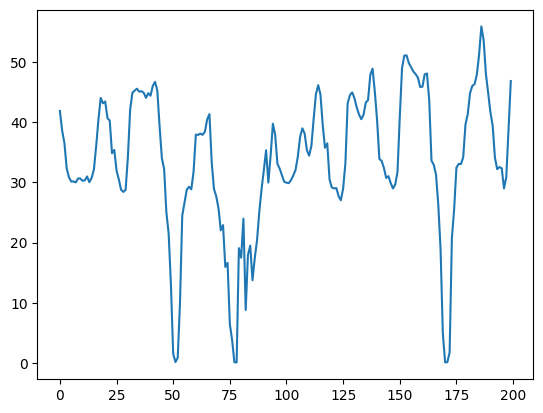

In [519]:
df["Deutschland/Luxemburg [€/MWh] Originalauflösungen"].iloc[:200].plot()

In [9]:
data = TimeSeriesDataFrame(df)

In [7]:
prediction_length = 120
train_data, test_data = data.train_test_split(prediction_length)

# prepare data - stock prices

In [158]:
# Fetch Bitcoin historical data
btc = yf.Ticker("BTC-USD")

# Get historical market data (e.g., daily data for the last 30 days)
btc_data = btc.history(period="30d", interval="1h")  # 1-hour intervals

In [159]:
btc_data = btc_data.reset_index(drop=False)
btc_data = btc_data[["Datetime", "Close"]]
btc_data = btc_data.rename(columns={"Datetime": "timestamp", "Close": "target"})
btc_data["item_id"] = 0

In [161]:
btc_data["timestamp"] = btc_data["timestamp"].dt.tz_localize(None)

In [163]:
data = TimeSeriesDataFrame.from_data_frame(btc_data)

In [164]:
prediction_length = 24
train_data, test_data = data.train_test_split(prediction_length)

# Zero shot

In [8]:
from src.data.preprocessor import read_smard_data
from autogluon.timeseries import TimeSeriesDataFrame
import pandas as pd

In [45]:
# alternative time series to consider (Großhandelspreise)
df, mapping = read_smard_data(file_paths=["data/Gro_handelspreise_201501010000_202101010000_Stunde.csv",
                                          "data/Gro_handelspreise_202101010000_202504240000_Stunde.csv"],
                              selected_time_series=["Deutschland/Luxemburg [€/MWh] Originalauflösungen"])

2025-04-29 16:58:36,331 - INFO - preprocessor.py - Starting to read SMARD data files...
2025-04-29 16:58:36,332 - INFO - preprocessor.py - Reading file: data/Gro_handelspreise_201501010000_202101010000_Stunde.csv
2025-04-29 16:58:36,507 - INFO - preprocessor.py - Reading file: data/Gro_handelspreise_202101010000_202504240000_Stunde.csv
2025-04-29 16:58:36,621 - INFO - preprocessor.py - Total number of rows after concatenation: 90383
2025-04-29 16:58:36,623 - INFO - preprocessor.py - Selected time series: ['Deutschland/Luxemburg [€/MWh] Originalauflösungen']
2025-04-29 16:58:36,624 - INFO - preprocessor.py - Columns retained: ['Deutschland/Luxemburg [€/MWh] Originalauflösungen', 'Datum von']
2025-04-29 16:58:36,628 - INFO - preprocessor.py - Number of rows after removing duplicates: 90373
2025-04-29 16:58:36,630 - INFO - preprocessor.py - Dataframe got melted. Number of rows: 90373
2025-04-29 16:58:36,636 - INFO - preprocessor.py - Encoded 1 unique time series.
2025-04-29 16:58:36,636 -

In [2]:
df, mapping = read_smard_data(file_paths=["data/Realisierter_Stromverbrauch_201501010000_202101010000_Stunde.csv",
                                          "data/Realisierter_Stromverbrauch_202101010000_202504240000_Stunde.csv"],
                              selected_time_series=["Netzlast [MWh] Berechnete Auflösungen", 
                                                    "Residuallast [MWh] Berechnete Auflösungen"])

2025-04-29 16:53:18,632 - INFO - preprocessor.py - Starting to read SMARD data files...
2025-04-29 16:53:18,632 - INFO - preprocessor.py - Reading file: data/Realisierter_Stromverbrauch_201501010000_202101010000_Stunde.csv
2025-04-29 16:53:18,775 - INFO - preprocessor.py - Reading file: data/Realisierter_Stromverbrauch_202101010000_202504240000_Stunde.csv
2025-04-29 16:53:18,873 - INFO - preprocessor.py - Total number of rows after concatenation: 90383
2025-04-29 16:53:18,874 - INFO - preprocessor.py - Selected time series: ['Netzlast [MWh] Berechnete Auflösungen', 'Residuallast [MWh] Berechnete Auflösungen']
2025-04-29 16:53:18,875 - INFO - preprocessor.py - Columns retained: ['Netzlast [MWh] Berechnete Auflösungen', 'Residuallast [MWh] Berechnete Auflösungen', 'Datum von']
2025-04-29 16:53:18,879 - INFO - preprocessor.py - Number of rows after removing duplicates: 90373
2025-04-29 16:53:18,882 - INFO - preprocessor.py - Dataframe got melted. Number of rows: 180746
2025-04-29 16:53:18

In [46]:
data = TimeSeriesDataFrame(df)

In [47]:
data_train, data_test = data.split_by_time(pd.Timestamp("01-02-2025"))

In [41]:
data_train

target
item_id timestamp                    
0       2015-01-01 00:00:00  44600.25
        2015-01-01 01:00:00  43454.75
        2015-01-01 02:00:00  41963.25
        2015-01-01 03:00:00  40617.75
        2015-01-01 04:00:00  39936.75
...                               ...
1       2025-01-01 19:00:00   7908.75
        2025-01-01 20:00:00   5860.25
        2025-01-01 21:00:00   5273.75
        2025-01-01 22:00:00   5069.25
        2025-01-01 23:00:00   2264.75

[175372 rows x 1 columns]

In [54]:
64*3

192

In [55]:
predictor = TimeSeriesPredictor(prediction_length=192, freq="1h").fit(
    data_train, presets="bolt_tiny",
)

No path specified. Models will be saved in: "AutogluonModels/ag-20250429_145939"
Frequency '1h' stored as 'h'
Beginning AutoGluon training...
AutoGluon will save models to '/Users/louisskowronek/Documents/thesis/master-thesis/AutogluonModels/ag-20250429_145939'
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.12.7
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 23.6.0: Thu Dec 19 20:47:53 PST 2024; root:xnu-10063.141.1.703.2~1/RELEASE_ARM64_T6030
CPU Count:          12
GPU Count:          0
Memory Avail:       10.60 GB / 36.00 GB (29.5%)
Disk Space Avail:   393.33 GB / 926.35 GB (42.5%)
Setting presets to: bolt_tiny

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'freq': 'h',
 'hyperparameters': {'Chronos': {'model_path': 'bolt_tiny'}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 192,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 

In [56]:
predictions = predictor.predict(data_train)

data with frequency 'None' has been resampled to frequency 'h'.
Model not specified in predict, will default to the model with the best validation score: Chronos[bolt_tiny]


/Users/louisskowronek/Documents/thesis/master-thesis/AutogluonModels/ag-20250429_145939/models/Chronos[bolt_tiny]
model
autogluon/chronos-bolt-tiny


In [37]:
predictions

mean           0.1           0.2  \
item_id timestamp                                                       
0       2025-02-01 00:00:00  49923.296875  48107.703125  48817.531250   
        2025-02-01 01:00:00  48081.820312  46119.406250  46877.101562   
        2025-02-01 02:00:00  46786.000000  44772.492188  45484.445312   
        2025-02-01 03:00:00  46019.324219  43893.132812  44611.687500   
        2025-02-01 04:00:00  45785.117188  43655.710938  44334.031250   
...                                   ...           ...           ...   
1       2025-02-04 03:00:00  31617.974609  23771.828125  26707.771484   
        2025-02-04 04:00:00  32827.562500  24578.234375  27711.484375   
        2025-02-04 05:00:00  35689.589844  26967.039062  30315.164062   
        2025-02-04 06:00:00  39790.414062  30179.935547  33922.214844   
        2025-02-04 07:00:00  43714.289062  32848.097656  37086.429688   

                                      0.3           0.4           0.5  \
item_id timestamp                                                       
0       2025-02-01 00:00:00  49234.628906  49585.570312  49923.296875   
        2025-02-01 01:00:00  47321.101562  47725.835938  48081.820312   
        2025-02-01 02:00:00  45983.687500  46396.687500  46786.000000   
        2025-02-01 03:00:00  45158.375000  45603.222656  46019.324219   
        2025-02-01 04:00:00  44881.992188  45354.636719  45785.117188   
...                                   ...           ...           ...   
1       2025-02-04 03:00:00  28645.406250  30217.150391  31617.974609   
        2025-02-04 04:00:00  29723.230469  31317.587891  32827.562500   
        2025-02-04 05:00:00  32444.738281  34147.843750  35689.589844   
        2025-02-04 06:00:00  36267.281250  38115.632812  39790.414062   
        2025-02-04 07:00:00  39739.890625  41834.820312  43714.289062   

                                      0.6           0.7           0.8  \
item_id timestamp                                                       
0       2025-02-01 00:00:00  50271.195312  50667.812500  51178.636719   
        2025-02-01 01:00:00  48463.058594  48881.347656  49413.988281   
        2025-02-01 02:00:00  47201.863281  47676.335938  48273.128906   
        2025-02-01 03:00:00  46462.757812  46938.976562  47570.843750   
        2025-02-01 04:00:00  46219.898438  46739.726562  47354.289062   
...                                   ...           ...           ...   
1       2025-02-04 03:00:00  33058.863281  34562.363281  36320.511719   
        2025-02-04 04:00:00  34309.492188  35783.296875  37641.582031   
        2025-02-04 05:00:00  37214.878906  38830.273438  40690.296875   
        2025-02-04 06:00:00  41425.878906  43168.023438  45199.585938   
        2025-02-04 07:00:00  45555.789062  47519.507812  49848.718750   

                                      0.9  
item_id timestamp                          
0       2025-02-01 00:00:00  51939.328125  
        2025-02-01 01:00:00  50244.710938  
        2025-02-01 02:00:00  49179.886719  
        2025-02-01 03:00:00  48607.187500  
        2025-02-01 04:00:00  48409.730469  
...                                   ...  
1       2025-02-04 03:00:00  38886.832031  
        2025-02-04 04:00:00  40257.257812  
        2025-02-04 05:00:00  43461.679688  
        2025-02-04 06:00:00  48225.171875  
        2025-02-04 07:00:00  53236.703125  

[160 rows x 10 columns]

data with frequency 'None' has been resampled to frequency 'h'.


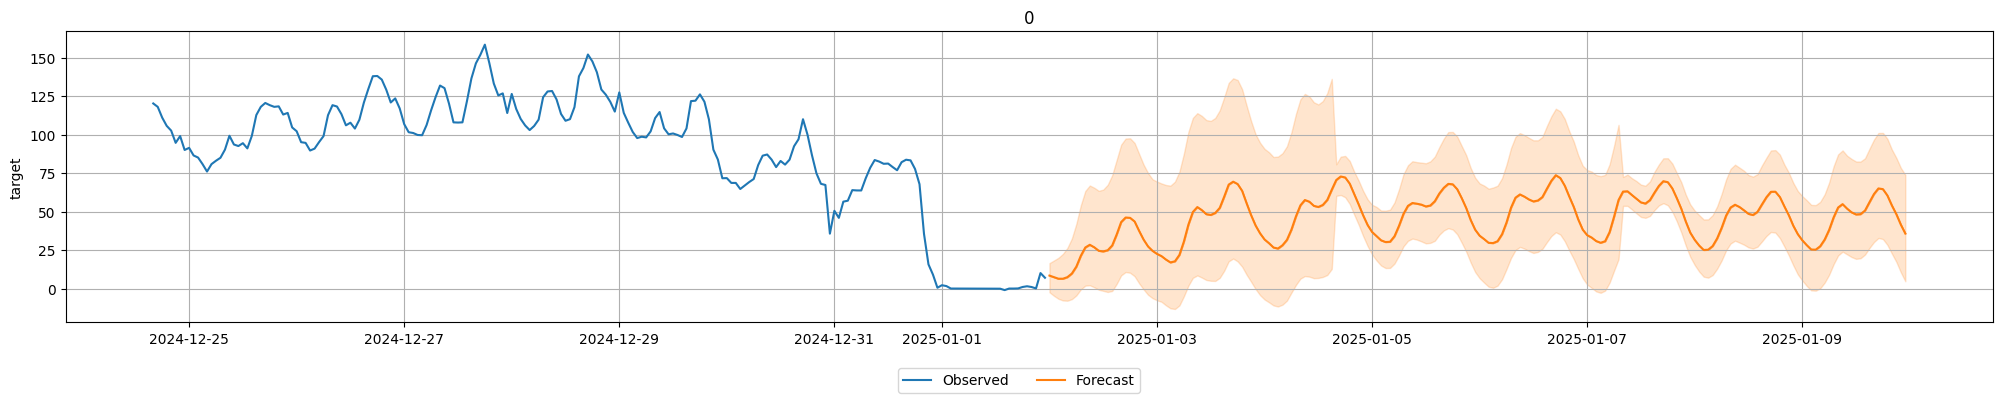

In [57]:
predictor.plot(
    data=data_train,
    predictions=predictions,
    quantile_levels=[0.1,0.5,0.9],
    item_ids=[0],
    max_history_length=200,
)

data with frequency 'None' has been resampled to frequency 'h'.


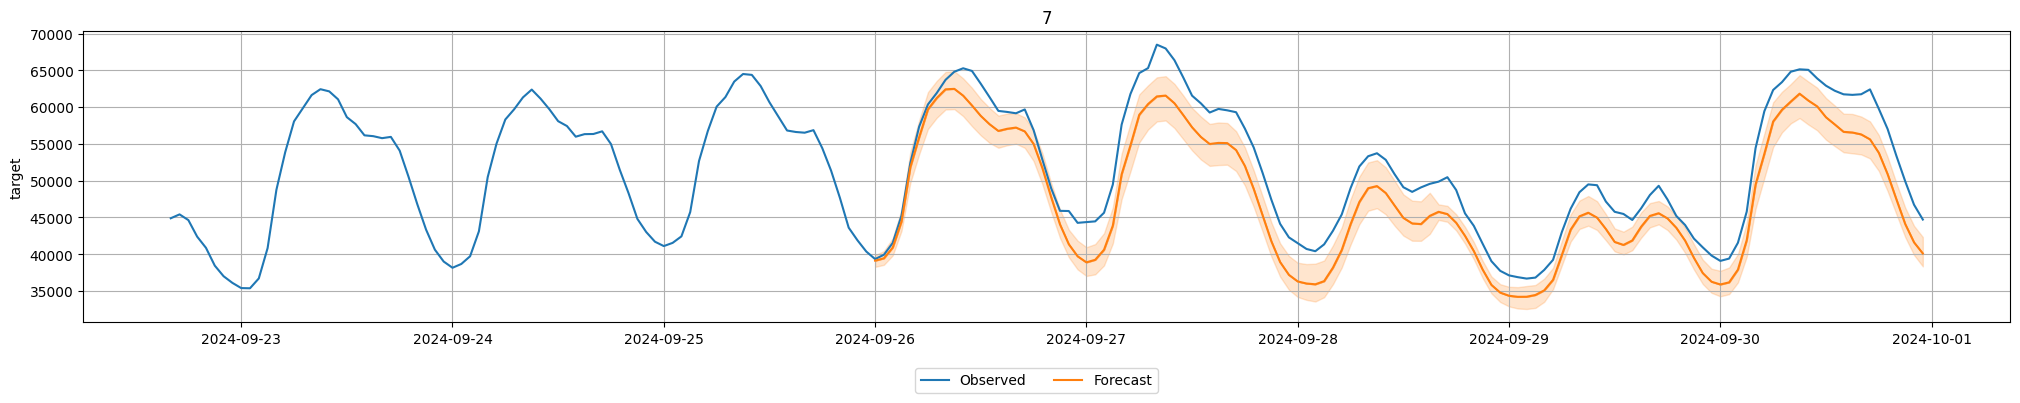

In [122]:
predictor.plot(
    data=data,
    predictions=predictions,
    quantile_levels=[0.1,0.5,0.9],
    item_ids=[values.get_loc("DE")],
    max_history_length=200,
)

data with frequency 'None' has been resampled to frequency 'h'.


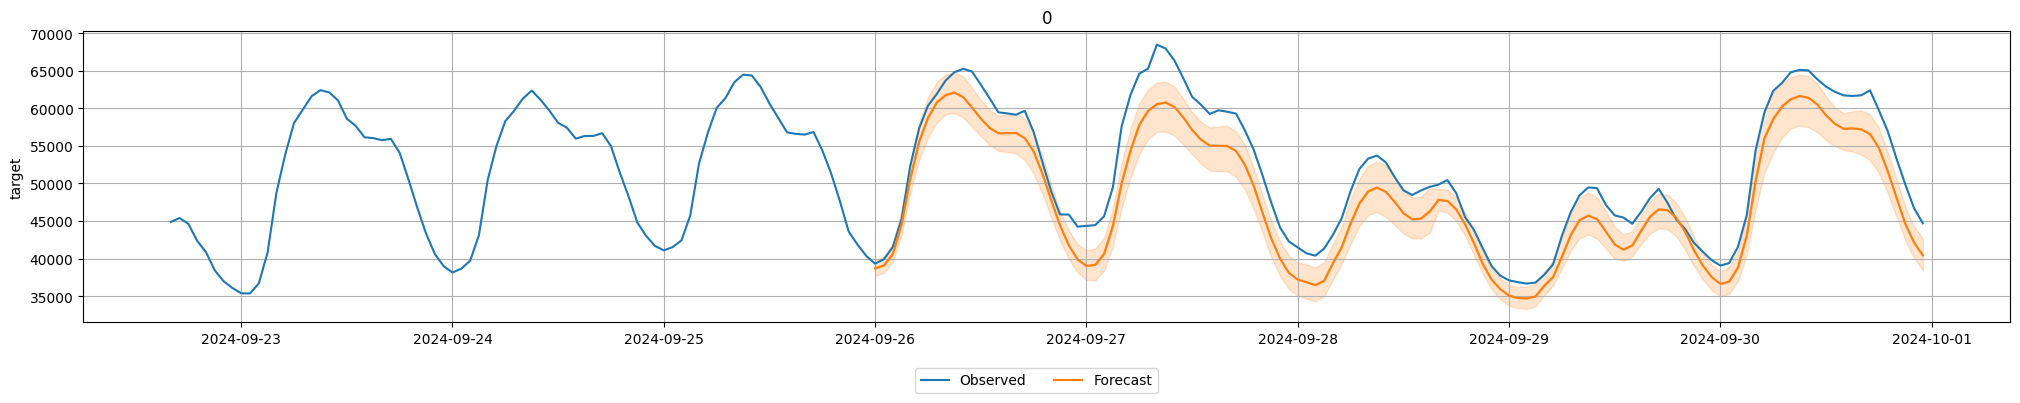

In [75]:
predictor.plot(
    data=data,
    predictions=predictions,
    quantile_levels=[0.1,0.5,0.9],
    item_ids=data.item_ids[:2],
    max_history_length=200,
)

# Fine tune

In [143]:
predictor = TimeSeriesPredictor(prediction_length=prediction_length, freq="1h").fit(
    train_data=train_data,
    hyperparameters={
        "Chronos": [
            {"model_path": "bolt_small", "ag_args": {"name_suffix": "ZeroShot"}},
            {"model_path": "bolt_small", "fine_tune": True, "ag_args": {"name_suffix": "FineTuned"}, "fine_tune_steps":5000, "device": "mps"},
        ]
    },
    time_limit=1000,  # time limit in seconds
    enable_ensemble=False,
)

NameError: name 'prediction_length' is not defined

In [194]:
predictions = predictor.predict(train_data, model="ChronosZeroShot[bolt_small]")

data with frequency 'None' has been resampled to frequency 'h'.


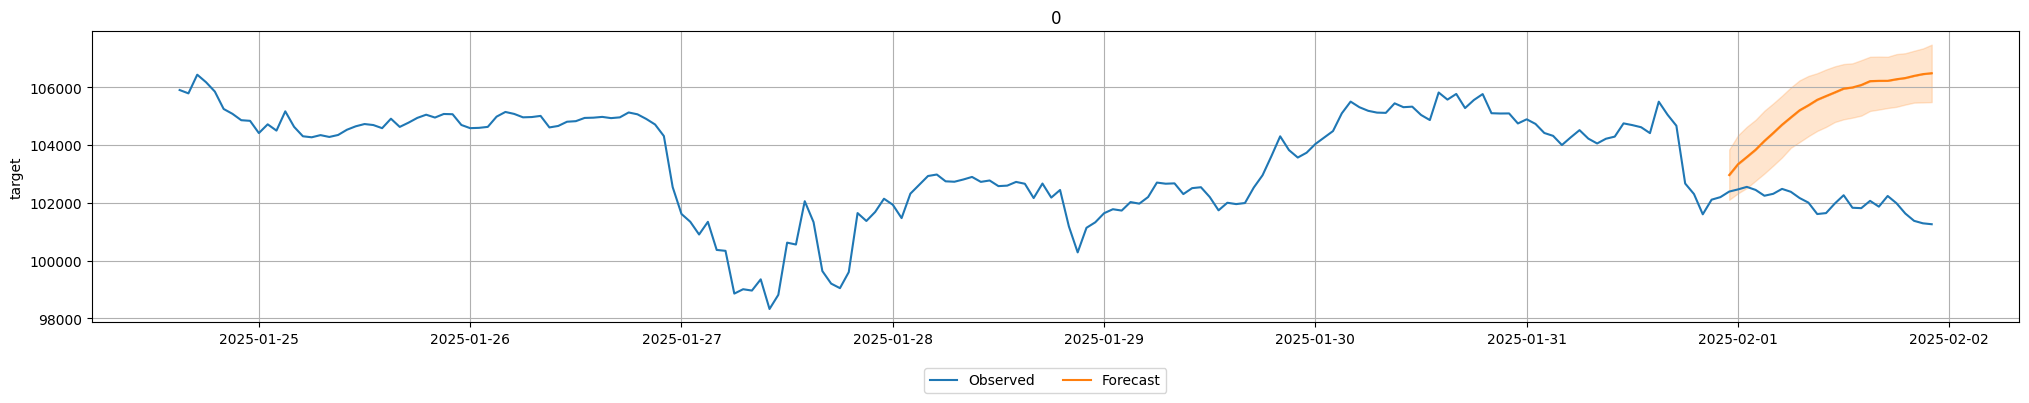

In [ ]:
predictor.plot(
    data=data,
    predictions=predictions,
    quantile_levels=[0.1,0.5,0.9],
    item_ids=data.item_ids[:1],
    max_history_length=200,
)

data with frequency 'None' has been resampled to frequency 'h'.


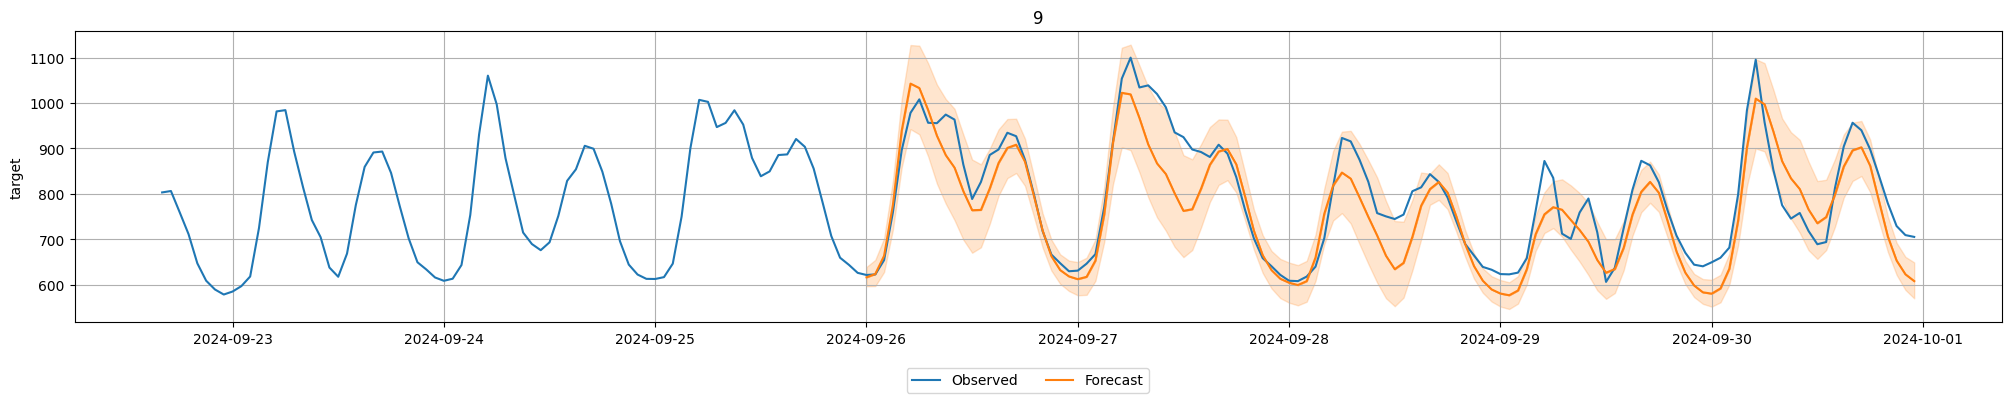

In [193]:
predictor.plot(
    data=data,
    predictions=predictions,
    quantile_levels=[0.1,0.5,0.9],
    item_ids=[9],
    max_history_length=200,
)

data with frequency 'None' has been resampled to frequency 'h'.


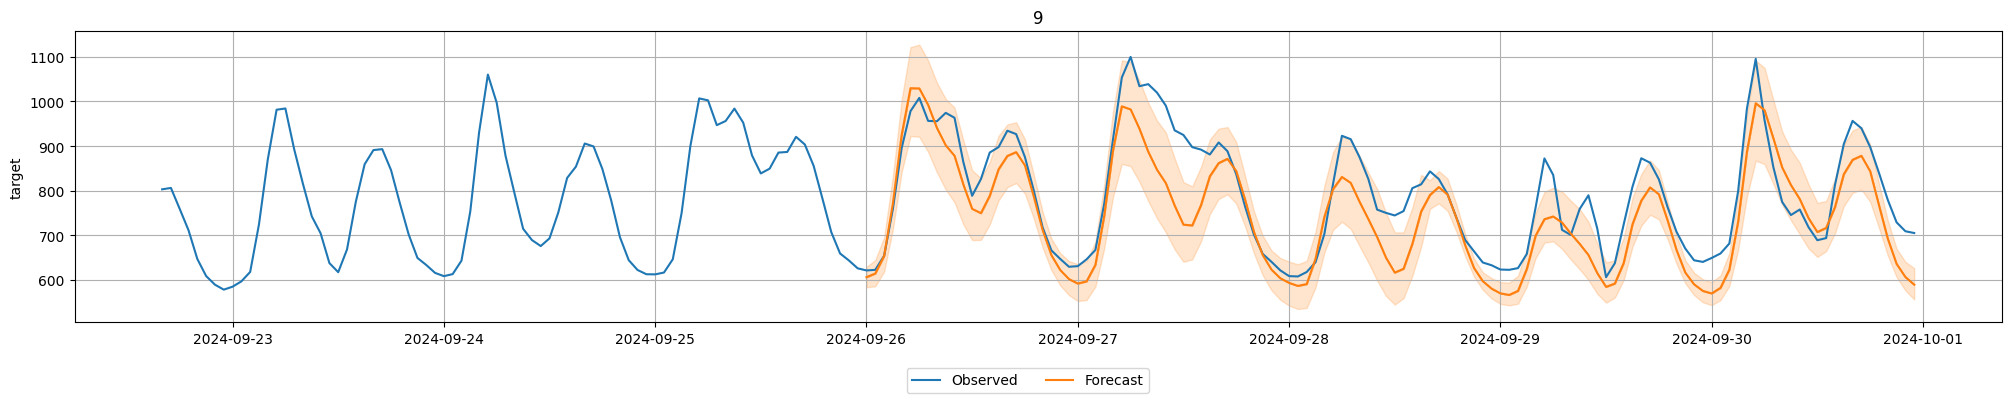

In [195]:
predictor.plot(
    data=data,
    predictions=predictions,
    quantile_levels=[0.1,0.5,0.9],
    item_ids=[9],
    max_history_length=200,
)

# Postprocess predictions

# Chronos Pytorch

In [ ]:
# einfacher benchmark
# nearest neighbour. gleicher Wochentag, gleiche Stunde. (20 samples)
# dann darauf die empirischen Quantile berechnen oder Normalverteilung 

# welche Modelle gibt es bei Autogluon?
# bisherige Analysen für 3 Zeitreihen durchführen
# quantile regression with pyqreg implementieren
# postprocessing with maximum likelihood estimation

In [ ]:
import pandas as pd
import torch
from typing import List
import numpy as np
from chronos import BaseChronosPipeline
from tqdm import tqdm
from core.timeseries import PredictionLeadTime, PredictionLeadTimes, TabularDataFrame
from data_preparation import ChronosBacktestingDataset
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import QuantileRegressor
import scoringrules as sr

In [131]:
data_train, data_test = data.split_by_time(pd.Timestamp("01-01-2023"))

In [132]:
pipeline = BaseChronosPipeline.from_pretrained(
   # "amazon/chronos-bolt-small",
    "amazon/chronos-bolt-tiny",
    device_map="mps",
    #torch_dtype=torch.bfloat16,
)

In [135]:
# make predictions for test data
freq = pd.Timedelta("1h")
prediction_length = 64
lead_time = np.arange(1,prediction_length+1)
results = {ld: None for ld in lead_time}

ds = ChronosBacktestingDataset(data_test, context_length=2048)
dl = DataLoader(ds, batch_size=64)

forecasts = []

for batch in tqdm(dl):
    forecast = pipeline.predict(context=batch, prediction_length=prediction_length)
    forecasts.append(forecast)

forecasts = torch.vstack(forecasts)

for lt in lead_time:
    results[lt] = PredictionLeadTime(lead_time=lt,
                                     predictions=forecasts[..., lt-1],
                                     freq=freq,
                                     data=data_test)

predictions = PredictionLeadTimes(results=results)

100%|██████████| 306/306 [00:12<00:00, 24.45it/s]


In [136]:
# small
predictions.get_crps()

{1: 614.4922082008098,
 2: 747.6605021673224,
 3: 837.1297197573348,
 4: 913.5434796784774,
 5: 970.9978606360938,
 6: 1020.2504691341857,
 7: 1061.9064708492872,
 8: 1088.654438207666,
 9: 1118.0452493108444,
 10: 1149.7327961767571,
 11: 1173.0910850823134,
 12: 1196.759311830442,
 13: 1214.3868745828363,
 14: 1235.7120379706735,
 15: 1249.3958284853063,
 16: 1256.0256565952338,
 17: 1267.980736655843,
 18: 1280.3071609953408,
 19: 1285.3103992154383,
 20: 1293.3891583714596,
 21: 1293.561713728224,
 22: 1299.0475025907137,
 23: 1309.4899926945686,
 24: 1321.525632761391,
 25: 1354.2864667381255,
 26: 1382.3296481179798,
 27: 1407.232484317177,
 28: 1432.1941530002875,
 29: 1453.2372872633189,
 30: 1471.4694895959478,
 31: 1479.1360729894266,
 32: 1482.3636916406886,
 33: 1486.815754035525,
 34: 1490.7739028020349,
 35: 1499.8664466502598,
 36: 1502.7350481840367,
 37: 1502.666816012568,
 38: 1510.8839419275942,
 39: 1516.4980372616867,
 40: 1522.6769087009804,
 41: 1525.330555365340

In [486]:
predictions.get_empirical_coverage_rates()

,1,2,3,4,5,6,7,8,9,10,...,55,56,57,58,59,60,61,62,63,64
0.1,0.024241,0.041531,0.050022,0.058850,0.069555,0.076869,0.080905,0.087462,0.086818,0.086481,...,0.100745,0.101278,0.104781,0.107779,0.107107,0.107359,0.108732,0.107471,0.102035,0.100045
0.2,0.095561,0.125378,0.136588,0.145892,0.158194,0.166797,0.175036,0.182323,0.179997,0.182575,...,0.188936,0.192327,0.195802,0.200118,0.201939,0.203200,0.201295,0.202079,0.191122,0.184256
0.3,0.203032,0.222817,0.228366,0.238370,0.249832,0.261350,0.268356,0.276314,0.277127,0.278444,...,0.275418,0.281106,0.288925,0.291251,0.294446,0.296772,0.290606,0.293129,0.282984,0.273008
0.4,0.329251,0.335416,0.332810,0.341526,0.344496,0.353716,0.364057,0.371315,0.379750,0.375098,...,0.365262,0.369521,0.378629,0.381011,0.383645,0.387793,0.382805,0.380703,0.373641,0.361927
0.5,0.473041,0.459982,0.450006,0.446671,0.451491,0.459758,0.469202,0.475367,0.479543,0.474554,...,0.458861,0.463653,0.475395,0.476600,0.480327,0.485596,0.476936,0.475451,0.463625,0.453593
0.6,0.619381,0.592899,0.571685,0.568014,0.569611,0.573955,0.578102,0.581269,0.584856,0.577009,...,0.558233,0.564343,0.572890,0.573450,0.576785,0.581745,0.574599,0.571208,0.563025,0.549434
0.7,0.757819,0.720127,0.702500,0.697091,0.691346,0.691206,0.693168,0.695129,0.695382,0.686218,...,0.656401,0.658390,0.666601,0.668339,0.672991,0.676073,0.673747,0.667694,0.659063,0.649311
0.8,0.881151,0.845029,0.827402,0.819387,0.814371,0.814090,0.810223,0.814118,0.809999,0.799854,...,0.762443,0.761041,0.769785,0.768748,0.776230,0.779677,0.778136,0.771102,0.763564,0.755100
0.9,0.971948,0.947932,0.939104,0.931902,0.927895,0.926802,0.924308,0.925877,0.923747,0.914415,...,0.886784,0.891016,0.891016,0.889390,0.894547,0.898442,0.894799,0.891184,0.885971,0.879134


In [12]:
predictions.get_empirical_coverage_rates([1])

,1
0.1,0.024241
0.2,0.095561
0.3,0.203032
0.4,0.329251
0.5,0.473041
0.6,0.619381
0.7,0.757819
0.8,0.881151
0.9,0.971948


<Figure size 800x800 with 0 Axes>

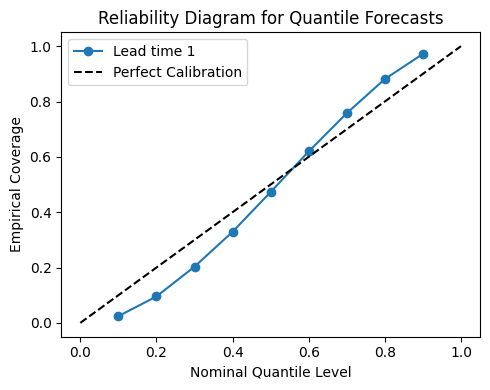

In [13]:
predictions.get_reliability_diagram([1])

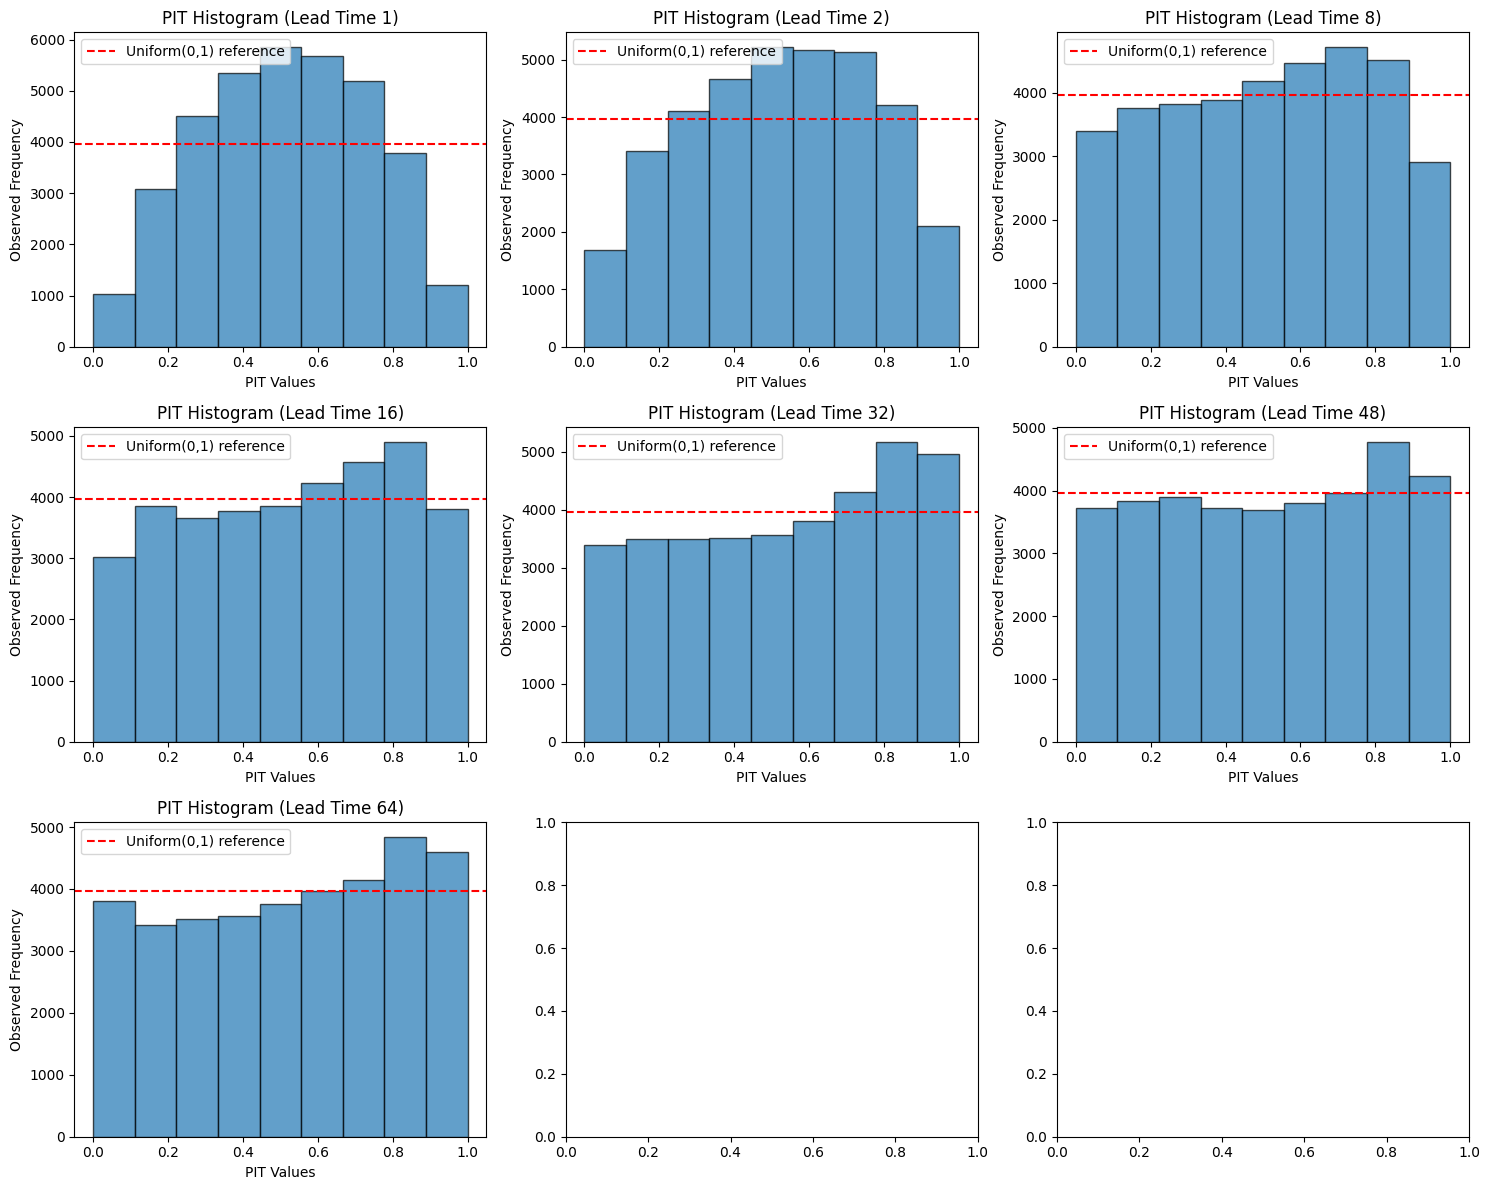

In [498]:
predictions.get_pit_histogram([1, 2, 8, 16, 32, 48, 64])

In [ ]:
# postprocessing, quantile regression based on a single regressor

In [113]:
train_end = pd.Timestamp("2021-04-01")
freq = pd.Timedelta("1h")
lead_time = np.arange(1,prediction_length+1)
results_qr = {ld: None for ld in lead_time}

for lt in lead_time:
        
    # prepare predictions for postprocessing
    prediction = predictions.results[lt]
    pred_df = prediction.to_dataframe().dropna()
    pred_df = pred_df.rename(columns={q: f"feature_{q}" for q in prediction.quantiles})
    cols_to_keep = [f"feature_{q}" for q in prediction.quantiles] + ["target"]
    q_data = TabularDataFrame(pred_df[cols_to_keep])
    train_data, test_data = q_data.split_by_time(train_end)

    # store results
    qr_models = {}
    test_results = {}

    # fit a quantile regression for each quantile and make predictions on test dataset
    for q in prediction.quantiles:

        x_train = train_data[f"feature_{q}"].values.reshape(-1, 1)
        y_train = train_data["target"].values
        x_test = test_data[f"feature_{q}"].values.reshape(-1, 1)
        y_test = test_data["target"].values

        qr_models[q] = QuantileRegressor(quantile=q)
        
        qr_models[q].fit(x_train, y_train)
        test_results[q] = qr_models[q].predict(x_test)

    results_qr[lt] = PredictionLeadTime(lead_time=lt,
                                    predictions=torch.tensor(np.array(list(test_results.values())).T),
                                    freq=freq,
                                    data=test_data)
    
predictions_qr = PredictionLeadTimes(results_qr)
   

Quantile level: 0.1
QS: 200.49734869359256
QS Postprocessed: 173.29434290201328

Quantile level: 0.2
QS: 289.75295518626547
QS Postprocessed: 264.7369530677141

Quantile level: 0.3
QS: 342.29015942800777
QS Postprocessed: 323.9840339126858

Quantile level: 0.4
QS: 368.3867328992807
QS Postprocessed: 354.979129304893

Quantile level: 0.5
QS: 374.73406047921736
QS Postprocessed: 363.519460144081

Quantile level: 0.6
QS: 364.09935808402525
QS Postprocessed: 353.45129213345825

Quantile level: 0.7
QS: 335.8353881515263
QS Postprocessed: 320.64486580032235

Quantile level: 0.8
QS: 284.2488889260664
QS Postprocessed: 261.77880219435065

Quantile level: 0.9
QS: 201.0440540057794
QS Postprocessed: 165.30160404533086



In [114]:
results_raw = results[1]

In [115]:
results_raw.get_crps()

614.3724376261493

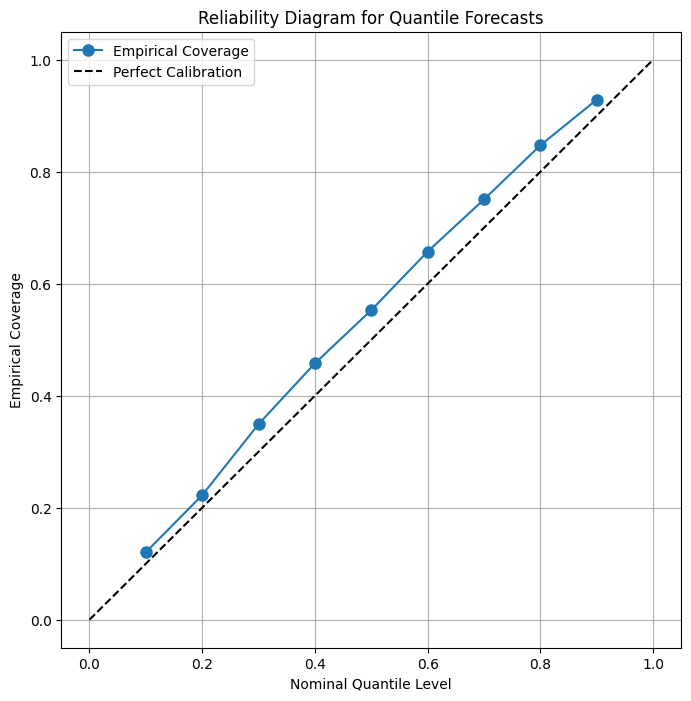

In [123]:
results_qr.get_reliability_diagram()

In [129]:
results_qr.to_dataframe()

0.1           0.2           0.3  \
item_id timestamp                                                       
0       2021-04-01 00:00:00  46017.026651  46580.698456  47082.432669   
        2021-04-01 01:00:00  44845.929907  45377.692311  45837.749957   
        2021-04-01 02:00:00  45235.290777  45512.914577  45804.668714   
        2021-04-01 03:00:00  45765.228783  46062.365782  46415.037829   
        2021-04-01 04:00:00  48987.454996  49314.343270  49688.405092   
...                                   ...           ...           ...   
        2025-03-26 13:00:00  60269.764019  60560.904862  60809.678310   
        2025-03-26 14:00:00  59949.327899  60121.685919  60315.188760   
        2025-03-26 15:00:00  60453.033526  60586.270161  60749.864712   
        2025-03-26 16:00:00  61851.571744  62053.642606  62224.409883   
        2025-03-26 17:00:00  63181.805306  63544.302687  63782.103764   

                                      0.4           0.5           0.6  \
item_id timestamp                                                       
0       2021-04-01 00:00:00  47366.153015  47577.041125  47823.943865   
        2021-04-01 01:00:00  46057.131279  46193.888895  46378.345523   
        2021-04-01 02:00:00  45928.040507  46012.167658  46191.305765   
        2021-04-01 03:00:00  46665.906156  46894.496626  47233.970681   
        2021-04-01 04:00:00  49992.889696  50271.435535  50673.159665   
...                                   ...           ...           ...   
        2025-03-26 13:00:00  61037.511900  61257.949832  61490.277424   
        2025-03-26 14:00:00  60524.961091  60722.171918  60963.750664   
        2025-03-26 15:00:00  60950.473683  61127.091249  61366.119207   
        2025-03-26 16:00:00  62426.333825  62569.840087  62779.814771   
        2025-03-26 17:00:00  64006.550395  64149.894356  64337.439446   

                                      0.7           0.8           0.9  \
item_id timestamp                                                       
0       2021-04-01 00:00:00  48039.697587  48198.116134  48265.303401   
        2021-04-01 01:00:00  46551.234289  46666.158556  46701.530800   
        2021-04-01 02:00:00  46375.967271  46576.103661  46772.954267   
        2021-04-01 03:00:00  47573.193492  47972.520338  48438.949384   
        2021-04-01 04:00:00  51080.893837  51571.295448  52222.691193   
...                                   ...           ...           ...   
        2025-03-26 13:00:00  61704.039675  61987.087814  62354.288447   
        2025-03-26 14:00:00  61164.595304  61429.388705  61808.196208   
        2025-03-26 15:00:00  61554.929473  61810.028914  62232.649302   
        2025-03-26 16:00:00  62937.052197  63162.779025  63576.109120   
        2025-03-26 17:00:00  64487.558957  64711.677365  65161.160118   

                                prediction_date    target  
item_id timestamp                                          
0       2021-04-01 00:00:00 2021-04-01 01:00:00  45936.00  
        2021-04-01 01:00:00 2021-04-01 02:00:00  45123.00  
        2021-04-01 02:00:00 2021-04-01 03:00:00  45253.75  
        2021-04-01 03:00:00 2021-04-01 04:00:00  46949.75  
        2021-04-01 04:00:00 2021-04-01 05:00:00  50323.75  
...                                         ...       ...  
        2025-03-26 13:00:00 2025-03-26 14:00:00  63059.50  
        2025-03-26 14:00:00 2025-03-26 15:00:00  62385.00  
        2025-03-26 15:00:00 2025-03-26 16:00:00  61922.00  
        2025-03-26 16:00:00 2025-03-26 17:00:00  63111.00  
        2025-03-26 17:00:00 2025-03-26 18:00:00  64575.25  

[34930 rows x 11 columns]

In [117]:
results_qr.get_crps()

573.708996334411

In [125]:
results_qr.get_empirical_coverage_rates()

{0.1: 0.12049813913541368,
 0.2: 0.2224162610936158,
 0.3: 0.34921271113655883,
 0.4: 0.4578299456054967,
 0.5: 0.5528199255654166,
 0.6: 0.6574864013741769,
 0.7: 0.7505582593758946,
 0.8: 0.8472087031205268,
 0.9: 0.9286286859433152}

In [96]:
results_raw.get_quantile_score()

0.1    200.729932
0.2    289.873396
0.3    342.312645
0.4    368.469898
0.5    375.042505
0.6    364.777189
0.7    336.695104
0.8    285.063493
0.9    201.711809
dtype: float64

In [126]:
results_qr.get_quantile_score()

0.1    173.294343
0.2    264.736953
0.3    323.984034
0.4    354.979129
0.5    363.519460
0.6    353.451292
0.7    320.644866
0.8    261.778802
0.9    165.301604
dtype: float64

In [67]:
results.to_dataframe()

0.1           0.2           0.3  \
item_id timestamp                                                       
0       2021-04-01 00:00:00  46017.026651  46580.698456  47082.432669   
        2021-04-01 01:00:00  44845.929907  45377.692311  45837.749957   
        2021-04-01 02:00:00  45235.290777  45512.914577  45804.668714   
        2021-04-01 03:00:00  45765.228783  46062.365782  46415.037829   
        2021-04-01 04:00:00  48987.454996  49314.343270  49688.405092   
...                                   ...           ...           ...   
        2025-03-26 13:00:00  60269.764019  60560.904862  60809.678310   
        2025-03-26 14:00:00  59949.327899  60121.685919  60315.188760   
        2025-03-26 15:00:00  60453.033526  60586.270161  60749.864712   
        2025-03-26 16:00:00  61851.571744  62053.642606  62224.409883   
        2025-03-26 17:00:00  63181.805306  63544.302687  63782.103764   

                                      0.4           0.5           0.6  \
item_id timestamp                                                       
0       2021-04-01 00:00:00  47366.153015  47577.041125  47823.943865   
        2021-04-01 01:00:00  46057.131279  46193.888895  46378.345523   
        2021-04-01 02:00:00  45928.040507  46012.167658  46191.305765   
        2021-04-01 03:00:00  46665.906156  46894.496626  47233.970681   
        2021-04-01 04:00:00  49992.889696  50271.435535  50673.159665   
...                                   ...           ...           ...   
        2025-03-26 13:00:00  61037.511900  61257.949832  61490.277424   
        2025-03-26 14:00:00  60524.961091  60722.171918  60963.750664   
        2025-03-26 15:00:00  60950.473683  61127.091249  61366.119207   
        2025-03-26 16:00:00  62426.333825  62569.840087  62779.814771   
        2025-03-26 17:00:00  64006.550395  64149.894356  64337.439446   

                                      0.7           0.8           0.9  \
item_id timestamp                                                       
0       2021-04-01 00:00:00  48039.697587  48198.116134  48265.303401   
        2021-04-01 01:00:00  46551.234289  46666.158556  46701.530800   
        2021-04-01 02:00:00  46375.967271  46576.103661  46772.954267   
        2021-04-01 03:00:00  47573.193492  47972.520338  48438.949384   
        2021-04-01 04:00:00  51080.893837  51571.295448  52222.691193   
...                                   ...           ...           ...   
        2025-03-26 13:00:00  61704.039675  61987.087814  62354.288447   
        2025-03-26 14:00:00  61164.595304  61429.388705  61808.196208   
        2025-03-26 15:00:00  61554.929473  61810.028914  62232.649302   
        2025-03-26 16:00:00  62937.052197  63162.779025  63576.109120   
        2025-03-26 17:00:00  64487.558957  64711.677365  65161.160118   

                                prediction_date   feature_0.1   feature_0.2  \
item_id timestamp                                                             
0       2021-04-01 00:00:00 2021-04-01 01:00:00  44157.003906  44799.324219   
        2021-04-01 01:00:00 2021-04-01 02:00:00  44544.539062  44935.847656   
        2021-04-01 02:00:00 2021-04-01 03:00:00  45071.992188  45490.585938   
        2021-04-01 03:00:00 2021-04-01 04:00:00  48279.109375  48773.855469   
        2021-04-01 04:00:00 2021-04-01 05:00:00  52784.855469  53463.105469   
...                                         ...           ...           ...   
        2025-03-26 13:00:00 2025-03-26 14:00:00  59189.582031  59685.191406   
        2025-03-26 14:00:00 2025-03-26 15:00:00  59690.925781  60154.246094   
        2025-03-26 15:00:00 2025-03-26 16:00:00  61082.906250  61635.738281   
        2025-03-26 16:00:00 2025-03-26 17:00:00  62406.902344  63140.742188   
        2025-03-26 17:00:00 2025-03-26 18:00:00           NaN           NaN   

                              feature_0.3   feature_0.4   feature_0.5  \
item_id timestamp                                                       
0       2021-0

In [68]:
results.get_quantile_score()

0.1    583.199470
0.2    780.441307
0.3    905.003755
0.4    964.432036
0.5    981.717054
0.6    959.714001
0.7    899.469209
0.8    789.805178
0.9    615.426170
dtype: float64

263.86520180842507

5123.774598510759

In [610]:
x_test

array([[39589.574],
       [39047.523],
       [38600.867],
       ...,
       [60154.246],
       [61635.74 ],
       [63140.742]], dtype=float32)

In [ ]:
# now I need to save the data
PredictionLeadTime(lead_time=1, 
                   predictions=
                   quantiles=q,
                   freq="1h",
                   data)

In [ ]:
# fit a linear regression model on the pinball loss 

In [599]:
test_data

{0.1: array([39548.11022093, 38916.03634447, 38335.70287366, ...,
        60327.51263059, 61714.83680896, 63034.40402572]),
 0.2: array([40232.81020803, 39698.48106929, 39258.18754397, ...,
        60504.53343311, 61964.92141147, 63448.48617855])}

In [574]:
y_pred = qr.predict(x_test)

In [572]:
y_test

array([60152.5 , 56639.5 , 52281.75, ..., 61922.  , 63111.  , 64575.25])

In [573]:
from sklearn import metrics

In [575]:
metrics.root_mean_squared_error(y_test, y_pred)

1573.43095245315

In [576]:
metrics.root_mean_squared_error(y_test, x_test)

2132.8500479835056

In [ ]:
plt.scatter(y_test, )

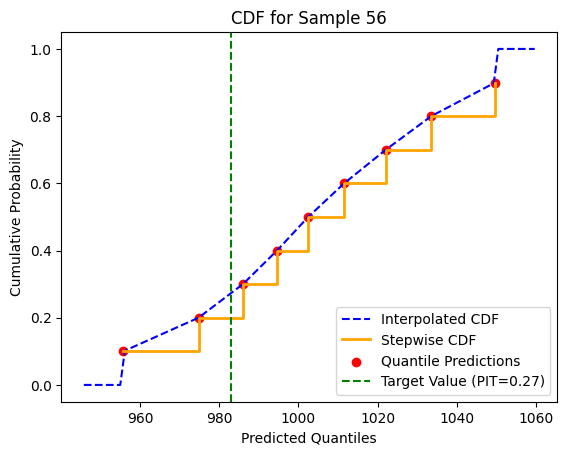

In [519]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Select one sample to visualize
i = 56  # Change this index to visualize different samples
y_target = targets[i]
q_preds = quantile_predictions[i]

# Interpolation function
interp_func = interp1d(q_preds, quantile_levels, bounds_error=False, fill_value=(0, 1))

# Generate x values for plotting (smooth function)
x_vals = np.linspace(q_preds.min() - 10, q_preds.max() + 10, 100)
y_vals = interp_func(x_vals)

# Plot the interpolated function (smooth CDF)
plt.plot(x_vals, y_vals, label="Interpolated CDF", color="blue", linestyle="dashed")

# Plot the stepwise CDF
plt.step(q_preds, quantile_levels, where="post", label="Stepwise CDF", color="orange", linestyle="solid", linewidth=2)

# Scatter plot for predicted quantiles
plt.scatter(q_preds, quantile_levels, color="red", label="Quantile Predictions")

# Show where the target value falls
y_target_pit = interp_func(y_target)
plt.axvline(y_target, color="green", linestyle="dashed", label=f"Target Value (PIT={y_target_pit:.2f})")

# Labels and title
plt.xlabel("Predicted Quantiles")
plt.ylabel("Cumulative Probability")
plt.title(f"CDF for Sample {i}")
plt.legend()
plt.show()


In [137]:
# simple quantile regression with dummy variables as benchmark

# Chronos predictions exchange rates

In [3]:
from pathlib import Path

In [4]:
ex_rates = {}
for f in Path("data/exchange_rates/").iterdir():
    file = pd.read_csv(f)
    file["observation_date"] = pd.to_datetime(file["observation_date"])
    file = file.rename(columns={"observation_date":"timestamp"})
    file.set_index("timestamp", inplace=True)
    symbol = f.name.removesuffix(".csv").removeprefix("DEX")

    if symbol.endswith("US"):
        file = 1/file
        symbol = symbol[2:] + symbol[:2]

    file.columns = [symbol]
    ex_rates[symbol] = file

df_ex_rates = pd.concat(ex_rates.values(), axis=1)
df_ex_rates = df_ex_rates.reset_index()
df_ex_rates = df_ex_rates.melt(id_vars="timestamp", var_name="item_id", value_name="target")

df_ex_rates["item_id"], mapping = pd.factorize(df_ex_rates["item_id"])
mapping = {i: m for i, m in zip(range(0, len(mapping)), mapping)}
data = TimeSeriesDataFrame(df_ex_rates)

In [ ]:
data.split_by_time(pd.Timestamp())

In [5]:
predictor = TimeSeriesPredictor(prediction_length=192, freq="1B").fit(
    data, presets="bolt_tiny",
)

Frequency '1B' stored as 'B'
Beginning AutoGluon training...
AutoGluon will save models to '/Users/louisskowronek/Documents/thesis/master-thesis/AutogluonModels/ag-20250503_095629'


=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.12.7
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 23.6.0: Thu Dec 19 20:47:53 PST 2024; root:xnu-10063.141.1.703.2~1/RELEASE_ARM64_T6030
CPU Count:          12
GPU Count:          0
Memory Avail:       15.82 GB / 36.00 GB (44.0%)
Disk Space Avail:   401.27 GB / 926.35 GB (43.3%)
Setting presets to: bolt_tiny

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'freq': 'B',
 'hyperparameters': {'Chronos': {'model_path': 'bolt_tiny'}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 192,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': True,
 'target': 'target',
 'verbosity': 2}

Provided train_data has 73712 rows (NaN fraction=3.9%), 8 time series. Median time series length is 9214

In [16]:
data_train, data_test = data.split_by_time(pd.Timestamp("2020-01-01"))

In [18]:
predictions = predictor.predict(data_train)

Model not specified in predict, will default to the model with the best validation score: Chronos[bolt_tiny]


/Users/louisskowronek/Documents/thesis/master-thesis/AutogluonModels/ag-20250503_095629/models/Chronos[bolt_tiny]
model
autogluon/chronos-bolt-tiny


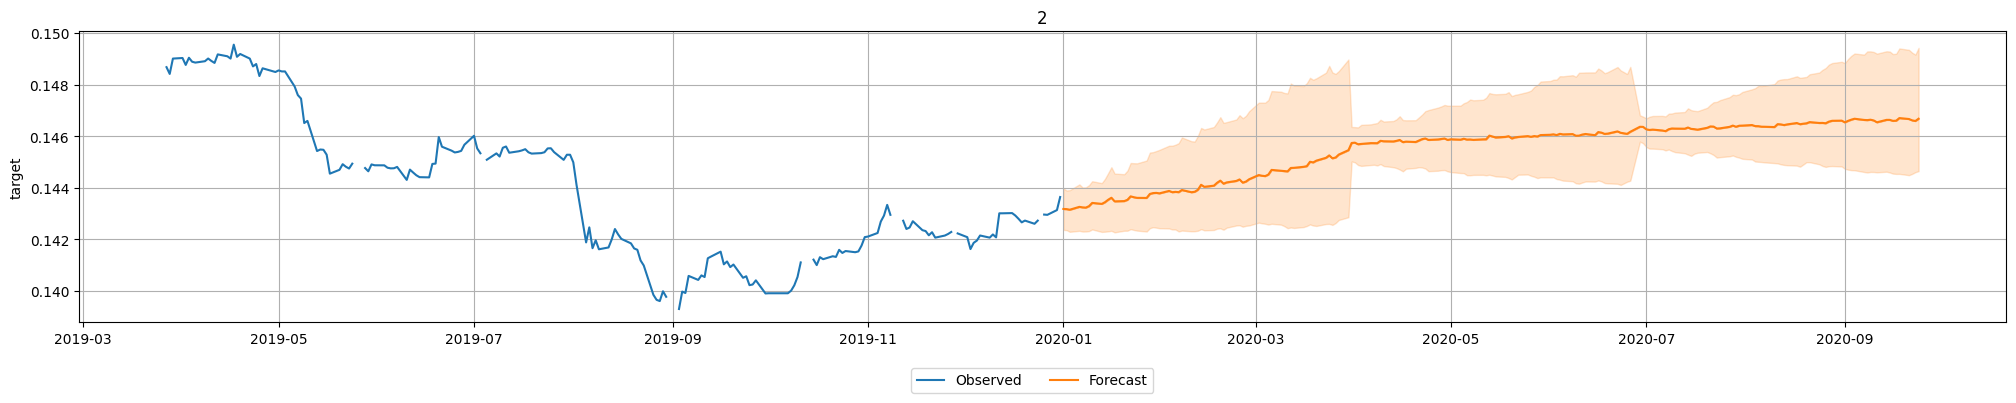

In [22]:
predictor.plot(
    data=data_train,
    predictions=predictions,
    quantile_levels=[0.1,0.5,0.9],
    item_ids=[2],
    max_history_length=200,
)